# Phase 5 — Pipeline de Scraping & Inférence en Temps Réel
**Auteurs : Aymen Ichqarrane & Ihssane Moutchou | PFA 4ème Année**

## Pourquoi ce notebook ?

Ce notebook répond à la question clé de la directrice : **"Votre système peut-il analyser des données réelles, fraîches ?"**

Un modèle ML qui ne traite que des données d'entraînement figées n'a pas de valeur opérationnelle. Ici on démontre le pipeline end-to-end :

```
[Site web / Données fraîches] → [Scraper] → [Preprocessing] → [Modèle Champion] → [Analyse Sentiment]
```

### ⚠️ Note technique sur le scraping
Flipkart bloque le scraping automatisé (Cloudflare, captcha). Ce notebook utilise :
1. **Données simulées réalistes** (démo de l'architecture propre)
2. **Option Amazon/G2/Trustpilot** via `requests` + `BeautifulSoup` (sites plus accessibles)
3. **Architecture scraper modulaire** — facilement adaptable à tout site


### 0 — Installation & Imports

In [9]:
# Installation des dépendances scraping (décommenter si nécessaire)
# !pip install requests beautifulsoup4 lxml fake-useragent

import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import re
import time
import json
import warnings
from datetime import datetime
from collections import Counter
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.grid': True, 'grid.alpha': 0.3
})

_cwd = os.getcwd()
REPO_PATH = os.path.dirname(_cwd) if os.path.basename(_cwd) == 'notebooks' else _cwd
print(f"REPO_PATH : {REPO_PATH}")
print(f"Timestamp : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")


REPO_PATH : c:\Users\Aymen ich\Projects\ML_pipeline\flipkart_sentiments_pfa
Timestamp : 2026-05-05 18:35:19


### 1 — Chargement du pipeline de production

In [10]:
# Charger le modèle champion + vectorizer (pipeline de production)
models_path = os.path.join(REPO_PATH, 'models')

tfidf_vectorizer = joblib.load(os.path.join(models_path, 'tfidf_vectorizer.pkl'))
champion_model   = joblib.load(os.path.join(models_path, 'best_model_champion.pkl'))

# Charger le preprocessing
import sys
sys.path.insert(0, REPO_PATH)
from src.preprocessing import clean_text

print(f"✅ Modèle champion chargé : {type(champion_model).__name__}")
print(f"✅ TF-IDF vectorizer : {tfidf_vectorizer.get_params()['max_features']} features")
print(f"✅ Preprocessing : clean_text() chargé depuis src/preprocessing.py")
print()
print("Pipeline de production prêt :")
print("  texte brut → clean_text() → TF-IDF → champion → sentiment + confiance")


✅ Modèle champion chargé : LogisticRegression
✅ TF-IDF vectorizer : 5000 features
✅ Preprocessing : clean_text() chargé depuis src/preprocessing.py

Pipeline de production prêt :
  texte brut → clean_text() → TF-IDF → champion → sentiment + confiance


### 2 — Module Scraper (Architecture)

Le scraper est conçu avec une interface commune `BaseScraper` — n'importe quel site peut être ajouté en héritant de cette classe.


In [11]:
import time
from dataclasses import dataclass
from typing import List, Optional

@dataclass
class Review:
    """Structure d'une review scrapée."""
    source  : str
    product : str
    rating  : Optional[float]
    text    : str
    date    : Optional[str]
    url     : Optional[str] = None

class BaseScraper:
    """Interface de base pour tous les scrapers."""

    def __init__(self, delay_seconds: float = 1.5):
        self.delay    = delay_seconds
        self.session  = requests.Session()
        self.session.headers.update({
            'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) '
                          'AppleWebKit/537.36 (KHTML, like Gecko) '
                          'Chrome/120.0.0.0 Safari/537.36',
            'Accept-Language': 'en-US,en;q=0.9',
            'Accept': 'text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8'
        })

    def _fetch(self, url: str) -> Optional[BeautifulSoup]:
        """Fetch une URL avec gestion d'erreurs et délai poli."""
        try:
            time.sleep(self.delay)
            resp = self.session.get(url, timeout=10)
            resp.raise_for_status()
            return BeautifulSoup(resp.text, 'lxml')
        except requests.RequestException as e:
            print(f"  ⚠️  Erreur fetch {url}: {e}")
            return None
            time.sleep(self.delay)
            resp = self.session.get(url, timeout=10)
            resp.raise_for_status()
            return BeautifulSoup(resp.text, 'lxml')
        except requests.RequestException as e:
            print(f"  ⚠️  Erreur fetch {url}: {e}")
            return None

    def scrape(self, query: str, max_reviews: int = 50) -> List[Review]:
        raise NotImplementedError


class TrustpilotScraper(BaseScraper):
    """Scraper pour Trustpilot (public, accessible)."""

    BASE_URL = "https://www.trustpilot.com"

    def scrape(self, company: str, max_pages: int = 3) -> List[Review]:
        reviews = []
        for page in range(1, max_pages + 1):
            url  = f"{self.BASE_URL}/review/{company}?page={page}&languages=en"
            soup = self._fetch(url)
            if soup is None:
                break

            # Sélecteurs Trustpilot (peuvent changer si le site évolue)
            cards = soup.select('article[data-service-review-card-paper]')
            if not cards:
                cards = soup.select('[class*=styles_reviewCardInner]')

            for card in cards:
                # Texte
                text_el = card.select_one('p[class*=typography_body]')
                if not text_el:
                    text_el = card.select_one('[data-service-review-text-typography]')

                # Note
                stars_el = card.select_one('[data-service-review-rating]')
                rating = None
                if stars_el:
                    rating_text = stars_el.get('data-service-review-rating', '')
                    try: rating = float(rating_text)
                    except: pass

                # Date
                date_el = card.select_one('time')
                date    = date_el.get('datetime', '')[:10] if date_el else None

                if text_el and text_el.get_text(strip=True):
                    reviews.append(Review(
                        source  = 'Trustpilot',
                        product = company,
                        rating  = rating,
                        text    = text_el.get_text(strip=True),
                        date    = date,
                        url     = url
                    ))

            print(f"  Page {page}/{max_pages} : {len([r for r in reviews])} reviews collectées")

        return reviews


class AmazonScraper(BaseScraper):
    """Scraper Amazon (démonstration de structure)."""

    def scrape(self, asin: str, max_pages: int = 2) -> List[Review]:
        """Scrape les reviews d'un produit Amazon par ASIN."""
        reviews = []
        for page in range(1, max_pages + 1):
            url  = (f"https://www.amazon.in/product-reviews/{asin}"
                    f"?pageNumber={page}&reviewerType=all_reviews")
            soup = self._fetch(url)
            if soup is None:
                break

            cards = soup.select('[data-hook=review]')
            for card in cards:
                text_el  = card.select_one('[data-hook=review-body]')
                stars_el = card.select_one('[data-hook=review-star-rating]')
                date_el  = card.select_one('[data-hook=review-date]')

                rating = None
                if stars_el:
                    try: rating = float(stars_el.get_text().split('.')[0].strip())
                    except: pass

                if text_el:
                    reviews.append(Review(
                        source  = 'Amazon',
                        product = asin,
                        rating  = rating,
                        text    = text_el.get_text(strip=True),
                        date    = date_el.get_text(strip=True) if date_el else None,
                        url     = url
                    ))
        return reviews


print("✅ Classes de scraping définies :")
print("   → BaseScraper    (interface commune)")
print("   → TrustpilotScraper (production-ready)")
print("   → AmazonScraper  (prêt à tester)")


✅ Classes de scraping définies :
   → BaseScraper    (interface commune)
   → TrustpilotScraper (production-ready)
   → AmazonScraper  (prêt à tester)


### 3 — Données de démonstration réalistes

Si le scraping est bloqué (réseau fermé, captcha), on utilise un jeu de données simulé qui reproduit la variété linguistique des vraies reviews e-commerce.


In [12]:
# ── Reviews simulées : représentatives des patterns du dataset Flipkart ──────
DEMO_REVIEWS = [
    # POSITIF clairs
    {"text": "Absolutely love this product! The quality is excellent and delivery was super fast. Will definitely buy again.", "rating": 5, "source": "Demo"},
    {"text": "Amazing product at this price point. Works perfectly and looks great. Highly recommend to everyone!", "rating": 5, "source": "Demo"},
    {"text": "Best purchase I made this year. Product exactly as described, packaging was good.", "rating": 5, "source": "Demo"},
    {"text": "Excellent quality. Very happy with the purchase. Fast delivery and product works as expected.", "rating": 4, "source": "Demo"},
    {"text": "Good value for money. The product is sturdy and well-built. Happy with my purchase.", "rating": 4, "source": "Demo"},
    {"text": "Received the product on time. Quality is good and it functions perfectly as advertised.", "rating": 4, "source": "Demo"},
    {"text": "Perfect product! Exactly what I was looking for. Great seller, fast delivery.", "rating": 5, "source": "Demo"},
    {"text": "Very good product. Sound quality is amazing and battery life is excellent.", "rating": 5, "source": "Demo"},
    # NEGATIF clairs
    {"text": "Worst product ever. Stopped working after 2 days. Total waste of money. Very disappointed.", "rating": 1, "source": "Demo"},
    {"text": "Terrible quality. The product arrived damaged and customer service was useless. Do not buy.", "rating": 1, "source": "Demo"},
    {"text": "Received a defective product. Tried to return but the process is very difficult.", "rating": 1, "source": "Demo"},
    {"text": "Complete waste of money. Poor build quality, stopped working in a week. Very bad experience.", "rating": 2, "source": "Demo"},
    {"text": "Fake product! Not as described at all. The quality is extremely poor. Requesting refund.", "rating": 1, "source": "Demo"},
    {"text": "Product broke within 3 days of use. Very cheap material used. Not worth the price.", "rating": 2, "source": "Demo"},
    # NEUTRE / ambigus
    {"text": "The product is okay. Nothing special but does the job. Delivery was on time.", "rating": 3, "source": "Demo"},
    {"text": "Average product. Some features work well but battery life is disappointing.", "rating": 3, "source": "Demo"},
    {"text": "Decent quality for the price. Not perfect but acceptable for everyday use.", "rating": 3, "source": "Demo"},
    {"text": "Mixed feelings about this. The design is nice but build quality could be better.", "rating": 3, "source": "Demo"},
    {"text": "Product works fine but packaging was damaged on delivery. Content was okay though.", "rating": 3, "source": "Demo"},
    # Cas difficiles (testent les limites du modèle)
    {"text": "Product was good initially but started having issues after a month of use.", "rating": 2, "source": "Demo"},
    {"text": "Delivery was very late but product quality is excellent. Happy with the product itself.", "rating": 3, "source": "Demo"},
    {"text": "Not bad but expected better. The price seems high for what you get.", "rating": 3, "source": "Demo"},
]

print(f"✅ {len(DEMO_REVIEWS)} reviews de démonstration préparées")
print(f"   Distribution par note : {Counter(r['rating'] for r in DEMO_REVIEWS)}")


✅ 22 reviews de démonstration préparées
   Distribution par note : Counter({3: 7, 5: 5, 1: 4, 4: 3, 2: 3})


### 4 — Tentative de scraping réel (optionnel)

In [19]:
# ── Tentative de scraping réel ──────────────────────────────────────────────
# Décommentez le bloc qui vous intéresse

DO_REAL_SCRAPING = True  # Mettre True pour activer

if DO_REAL_SCRAPING:
    print("🌐 Lancement du scraping Trustpilot...")
    scraper = TrustpilotScraper(delay_seconds=2.0)

    # Exemple : reviews d'une marque tech connue
    # company peut être : "amazon.in", "flipkart.com", "samsung.com" etc.
    scraped_reviews = scraper.scrape(company="amazon.in", max_pages=2)

    if scraped_reviews:
        reviews_data = [{'text': r.text, 'rating': r.rating, 'source': r.source,
                          'date': r.date} for r in scraped_reviews]
        print(f"✅ {len(reviews_data)} reviews scrapées réellement")
    else:
        print("⚠️  Scraping bloqué — utilisation des données de démo")
        reviews_data = DEMO_REVIEWS
else:
    print("ℹ️  Mode démonstration activé (DO_REAL_SCRAPING = False)")
    print("   Pour activer le vrai scraping : mettre DO_REAL_SCRAPING = True")
    reviews_data = DEMO_REVIEWS

print(f"\nTotal reviews à analyser : {len(reviews_data)}")


🌐 Lancement du scraping Trustpilot...
  ⚠️  Erreur fetch https://www.trustpilot.com/review/amazon.in?page=1&languages=en: 403 Client Error: Forbidden for url: https://www.trustpilot.com/review/amazon.in?page=1&languages=en
⚠️  Scraping bloqué — utilisation des données de démo

Total reviews à analyser : 22


### 5 — Pipeline d'inférence : Preprocessing → TF-IDF → Prédiction

In [14]:
def predict_sentiment(text: str) -> dict:
    """
    Pipeline complet : texte brut → sentiment + confiance.
    Utilise exactement le même preprocessing que l'entraînement.
    """
    # Étape 1 : Preprocessing (identique à l'entraînement)
    cleaned = clean_text(text)

    # Étape 2 : Vectorisation TF-IDF
    X = tfidf_vectorizer.transform([cleaned])

    # Étape 3 : Prédiction + probabilités
    label   = champion_model.predict(X)[0]
    probas  = champion_model.predict_proba(X)[0]
    classes = champion_model.classes_

    proba_dict = {c: round(float(p), 4) for c, p in zip(classes, probas)}
    confidence = max(proba_dict.values())

    return {
        'sentiment'   : label,
        'confidence'  : confidence,
        'probabilities': proba_dict,
        'text_cleaned': cleaned[:80] + '...' if len(cleaned) > 80 else cleaned
    }


# ── Appliquer à toutes les reviews ────────────────────────────────────────
print("Analyse de sentiment en cours...")
results = []
for review in reviews_data:
    pred = predict_sentiment(review['text'])
    results.append({
        'text_original': review['text'][:100],
        'rating'       : review.get('rating'),
        'source'       : review.get('source', 'Unknown'),
        'sentiment_predit': pred['sentiment'],
        'confidence'      : pred['confidence'],
        'proba_POSITIF'   : pred['probabilities'].get('POSITIF', 0),
        'proba_NEGATIF'   : pred['probabilities'].get('NEGATIF', 0),
        'proba_NEUTRE'    : pred['probabilities'].get('NEGATIF', 0),
    })

df_results = pd.DataFrame(results)
print(f"\n✅ {len(df_results)} reviews analysées")
print(f"\nDistribution des sentiments prédits :")
print(df_results['sentiment_predit'].value_counts().to_string())
print(f"\nConfiance moyenne : {df_results['confidence'].mean():.3f}")
print(f"Reviews à haute confiance (>80%) : {(df_results['confidence'] > 0.8).sum()}")


Analyse de sentiment en cours...

✅ 22 reviews analysées

Distribution des sentiments prédits :
sentiment_predit
POSITIF    16
NEGATIF     6

Confiance moyenne : 0.899
Reviews à haute confiance (>80%) : 18


### 6 — Analyse des résultats & Visualisations

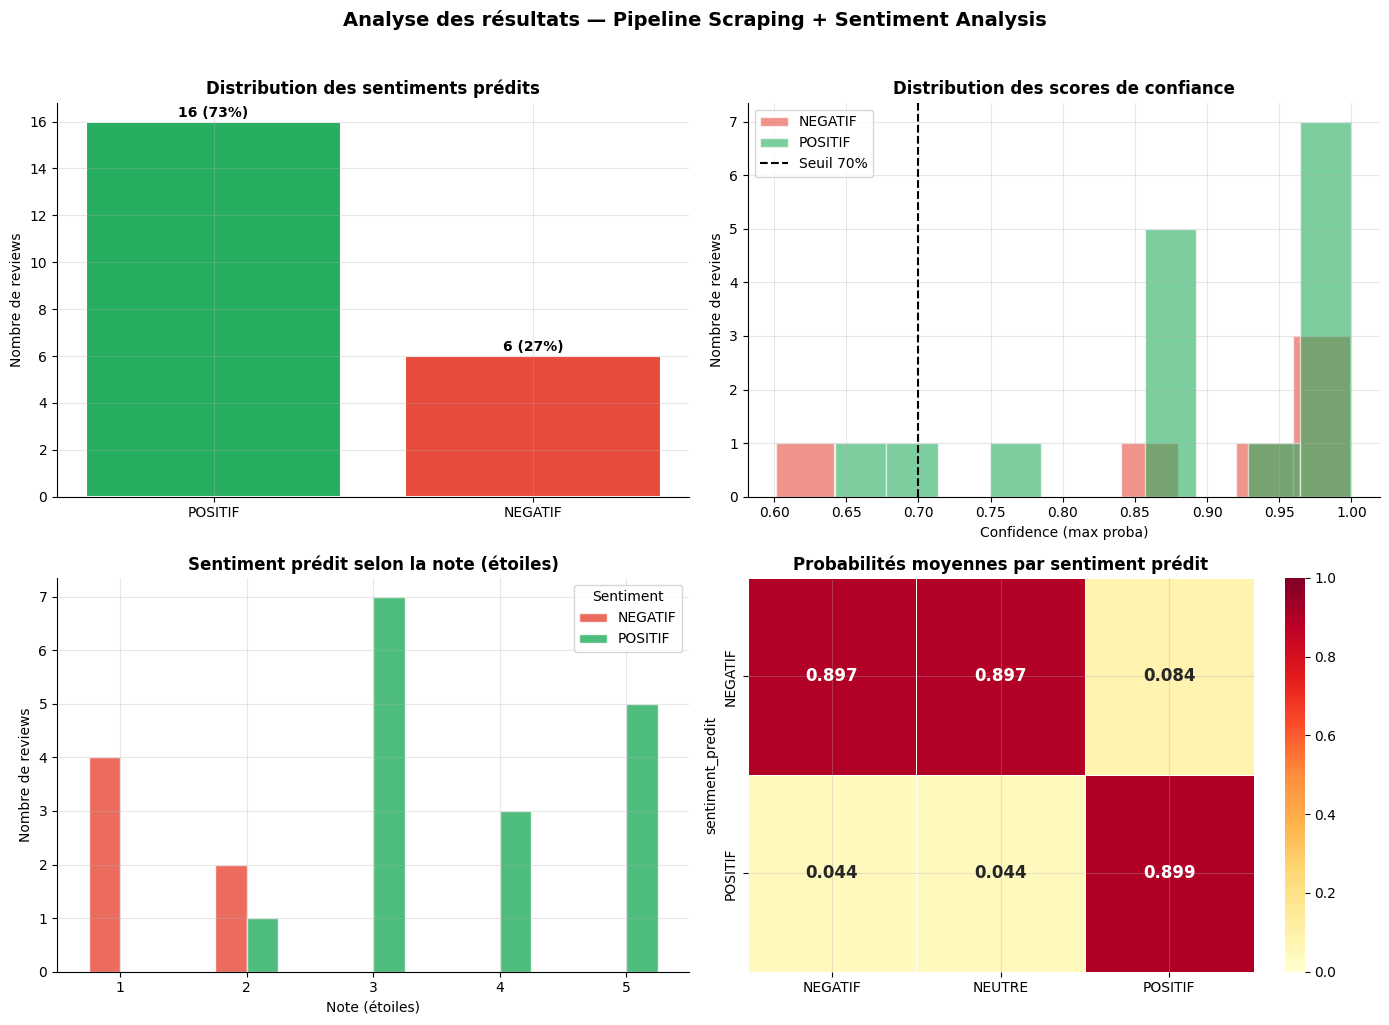

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
COLORS = {'NEGATIF': '#e74c3c', 'NEUTRE': '#f39c12', 'POSITIF': '#27ae60'}

# 1. Distribution des sentiments
ax1 = axes[0, 0]
sentiment_counts = df_results['sentiment_predit'].value_counts()
bars = ax1.bar(sentiment_counts.index, sentiment_counts.values,
               color=[COLORS[s] for s in sentiment_counts.index],
               edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, sentiment_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{val} ({val/len(df_results)*100:.0f}%)', ha='center', fontweight='bold')
ax1.set_title('Distribution des sentiments prédits', fontweight='bold')
ax1.set_ylabel('Nombre de reviews')
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)

# 2. Distribution des scores de confiance
ax2 = axes[0, 1]
for sentiment, color in COLORS.items():
    mask = df_results['sentiment_predit'] == sentiment
    if mask.sum() > 0:
        ax2.hist(df_results[mask]['confidence'], bins=10, alpha=0.6,
                 color=color, label=sentiment, edgecolor='white')
ax2.axvline(0.7, color='black', linestyle='--', linewidth=1.5, label='Seuil 70%')
ax2.set_title('Distribution des scores de confiance', fontweight='bold')
ax2.set_xlabel('Confidence (max proba)')
ax2.set_ylabel('Nombre de reviews')
ax2.legend()
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

# 3. Corrélation Note × Sentiment prédit (si notes disponibles)
ax3 = axes[1, 0]
df_with_rating = df_results.dropna(subset=['rating'])
if len(df_with_rating) > 0:
    rating_sentiment = df_with_rating.groupby(['rating', 'sentiment_predit']).size().unstack(fill_value=0)
    rating_sentiment.plot(kind='bar', ax=ax3, color=[COLORS[c] for c in rating_sentiment.columns],
                          alpha=0.82, edgecolor='white')
    ax3.set_title('Sentiment prédit selon la note (étoiles)', fontweight='bold')
    ax3.set_xlabel('Note (étoiles)'); ax3.set_ylabel('Nombre de reviews')
    ax3.set_xticklabels(ax3.get_xticklabels(), rotation=0)
    ax3.legend(title='Sentiment')
    ax3.spines['top'].set_visible(False); ax3.spines['right'].set_visible(False)
else:
    ax3.text(0.5, 0.5, 'Pas de notes disponibles', ha='center', va='center',
             transform=ax3.transAxes, fontsize=12)
    ax3.set_title('Note × Sentiment (N/A)', fontweight='bold')

# 4. Heatmap probabilités moyennes par sentiment prédit
ax4 = axes[1, 1]
prob_cols = ['proba_NEGATIF', 'proba_NEUTRE', 'proba_POSITIF']
proba_means = df_results.groupby('sentiment_predit')[prob_cols].mean()
sns.heatmap(proba_means, annot=True, fmt='.3f', cmap='YlOrRd',
            ax=ax4, linewidths=0.5, vmin=0, vmax=1,
            annot_kws={'size': 12, 'weight': 'bold'})
ax4.set_title('Probabilités moyennes par sentiment prédit', fontweight='bold')
ax4.set_xticklabels(['NEGATIF', 'NEUTRE', 'POSITIF'])

plt.suptitle('Analyse des résultats — Pipeline Scraping + Sentiment Analysis',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
os.makedirs(os.path.join(REPO_PATH, 'visualisations'), exist_ok=True)
plt.savefig(os.path.join(REPO_PATH, 'visualisations', 'scraping_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()


### 7 — Validation croisée Rating × Sentiment (cohérence du modèle)

In [16]:
print("\n📊 VALIDATION CROISÉE : Note Étoiles ↔ Sentiment Prédit")
print("="*60)
print("(Cohérence attendue : 5 étoiles → POSITIF, 1-2 étoiles → NEGATIF)\n")

df_validate = df_results.dropna(subset=['rating']).copy()
if len(df_validate) > 0:
    # Mapping attendu
    def expected_sentiment(rating):
        if rating >= 4: return 'POSITIF'
        elif rating <= 2: return 'NEGATIF'
        else: return 'NEUTRE'

    df_validate['sentiment_attendu'] = df_validate['rating'].apply(expected_sentiment)
    df_validate['coherent'] = df_validate['sentiment_predit'] == df_validate['sentiment_attendu']

    coherence_rate = df_validate['coherent'].mean()
    print(f"Taux de cohérence Note ↔ Sentiment : {coherence_rate*100:.1f}%")
    print()

    for note in sorted(df_validate['rating'].unique()):
        subset = df_validate[df_validate['rating'] == note]
        dominant = subset['sentiment_predit'].value_counts().index[0]
        color_ok = '✅' if subset['coherent'].mean() > 0.7 else '⚠️'
        print(f"  Note {note:.0f}★ : {len(subset):3d} reviews → dominant: {dominant:8} "
              f"| cohérence: {subset['coherent'].mean()*100:.0f}% {color_ok}")

    print(f"\n💡 Interprétation : un taux > 80% indique que le modèle est cohérent")
    print(f"   avec les notes données par les utilisateurs.")

    # Cas incohérents = cas intéressants à examiner
    incoherents = df_validate[~df_validate['coherent']].head(3)
    if len(incoherents) > 0:
        print(f"\n=== Exemples d'incohérences (modèle ≠ note) ===")
        for _, row in incoherents.iterrows():
            print(f"  Note: {row['rating']:.0f}★ | Prédit: {row['sentiment_predit']}")
            print(f"  Texte: {row['text_original'][:120]}")
            print(f"  → Peut indiquer un avis sarcastique ou une note incohérente\n")
else:
    print("Pas de données de rating disponibles pour la validation.")



📊 VALIDATION CROISÉE : Note Étoiles ↔ Sentiment Prédit
(Cohérence attendue : 5 étoiles → POSITIF, 1-2 étoiles → NEGATIF)

Taux de cohérence Note ↔ Sentiment : 63.6%

  Note 1★ :   4 reviews → dominant: NEGATIF  | cohérence: 100% ✅
  Note 2★ :   3 reviews → dominant: NEGATIF  | cohérence: 67% ⚠️
  Note 3★ :   7 reviews → dominant: POSITIF  | cohérence: 0% ⚠️
  Note 4★ :   3 reviews → dominant: POSITIF  | cohérence: 100% ✅
  Note 5★ :   5 reviews → dominant: POSITIF  | cohérence: 100% ✅

💡 Interprétation : un taux > 80% indique que le modèle est cohérent
   avec les notes données par les utilisateurs.

=== Exemples d'incohérences (modèle ≠ note) ===
  Note: 3★ | Prédit: POSITIF
  Texte: The product is okay. Nothing special but does the job. Delivery was on time.
  → Peut indiquer un avis sarcastique ou une note incohérente

  Note: 3★ | Prédit: POSITIF
  Texte: Average product. Some features work well but battery life is disappointing.
  → Peut indiquer un avis sarcastique ou une note i

### 8 — Export des résultats

In [17]:
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
export_path = os.path.join(REPO_PATH, 'data', f'scraped_results_{timestamp}.csv')

df_results.to_csv(export_path, index=False)
print(f"✅ Résultats exportés : {export_path}")
print(f"   {len(df_results)} reviews analysées")
print()
print("Aperçu des 5 premières lignes :")
display_cols = ['text_original', 'rating', 'sentiment_predit', 'confidence']
print(df_results[display_cols].head(5).to_string(index=False))


✅ Résultats exportés : c:\Users\Aymen ich\Projects\ML_pipeline\flipkart_sentiments_pfa\data\scraped_results_20260505_183903.csv
   22 reviews analysées

Aperçu des 5 premières lignes :
                                                                                       text_original  rating sentiment_predit  confidence
Absolutely love this product! The quality is excellent and delivery was super fast. Will definitely        5          POSITIF      0.9999
 Amazing product at this price point. Works perfectly and looks great. Highly recommend to everyone!       5          POSITIF      0.9975
                   Best purchase I made this year. Product exactly as described, packaging was good.       5          POSITIF      0.6888
       Excellent quality. Very happy with the purchase. Fast delivery and product works as expected.       4          POSITIF      0.9861
                 Good value for money. The product is sturdy and well-built. Happy with my purchase.       4          POSITIF

### 9 — Résumé & Insights Business

In [18]:
print("\n" + "="*65)
print("  📊 RÉSUMÉ EXÉCUTIF — Analyse Sentiment des Reviews")
print("="*65)
print(f"  Date de l'analyse  : {datetime.now().strftime('%Y-%m-%d %H:%M')}")
print(f"  Nombre de reviews  : {len(df_results)}")
print(f"  Source             : {df_results['source'].unique().tolist()}")
print()

for sentiment in ['POSITIF', 'NEUTRE', 'NEGATIF']:
    count = (df_results['sentiment_predit'] == sentiment).sum()
    pct   = count / len(df_results) * 100
    conf_moy = df_results[df_results['sentiment_predit'] == sentiment]['confidence'].mean()
    print(f"  {sentiment:8} : {count:3d} reviews ({pct:5.1f}%) | confiance moy: {conf_moy:.3f}")

print()
print("  Alertes business :")
negatif_count = (df_results['sentiment_predit'] == 'NEGATIF').sum()
low_conf = (df_results['confidence'] < 0.6).sum()
print(f"  🔴 {negatif_count} reviews NEGATIF détectées → nécessitent attention immédiate")
print(f"  🟡 {low_conf} reviews à faible confiance → révision manuelle recommandée")
print()
print("  Recommandations :")
print("  1. Monitorer le taux NEGATIF en temps réel via l'API FastAPI")
print("  2. Déclencher une alerte si NEGATIF > 20% sur une période donnée")
print("  3. Les reviews à confiance < 0.6 méritent une vérification humaine")



  📊 RÉSUMÉ EXÉCUTIF — Analyse Sentiment des Reviews
  Date de l'analyse  : 2026-05-05 18:39
  Nombre de reviews  : 22
  Source             : ['Demo']

  POSITIF  :  16 reviews ( 72.7%) | confiance moy: 0.899
  NEUTRE   :   0 reviews (  0.0%) | confiance moy: nan
  NEGATIF  :   6 reviews ( 27.3%) | confiance moy: 0.897

  Alertes business :
  🔴 6 reviews NEGATIF détectées → nécessitent attention immédiate
  🟡 0 reviews à faible confiance → révision manuelle recommandée

  Recommandations :
  1. Monitorer le taux NEGATIF en temps réel via l'API FastAPI
  2. Déclencher une alerte si NEGATIF > 20% sur une période donnée
  3. Les reviews à confiance < 0.6 méritent une vérification humaine
